<a href="https://colab.research.google.com/github/EduardoAve/Natural-language-processing/blob/main/sesion_3/transformers_newspolyml_eduardo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transformers
## Detección de Desinformación con NewsPolyML

**Autor:** Eduardo José Avendaño Caicedo  
**Curso:** Procesamiento de Lenguaje Natural — Maestría en Inteligencia Artificial Aplicada

---

En este notebook reimplementamos un clasificador de texto con Transformers
construidos desde cero, siguiendo la estructura del notebook guía
`1-transformers-from-scratch`, pero cambiando el dataset y el dominio del problema.

**Problema:** Detección de desinformación en noticias multilingües. Dado el
*claim* (declaración) de una noticia verificada por una agencia de fact-checking,
el modelo debe predecir su etiqueta de veracidad normalizada. Las etiquetas
originales del dataset fueron preprocesadas: `OTHER` se fusionó con `MIXTURE`
por compartir la misma ambigüedad semántica, y los registros `MISLABELED`
fueron eliminados, resultando en tres clases finales:

| Etiqueta | Descripción | Proporción (español) |
|----------|-------------|----------------------|
| `FALSE`   | Afirmación comprobadamente incorrecta | 79.5% |
| `MIXTURE` | Mezcla de verdad y falsedad, o no verificable | 17.2% |
| `TRUE`    | Afirmación verificada como precisa | 3.3% |

**¿Por qué es interesante este dominio?**
- El dataset cubre **5 idiomas europeos** (español, inglés, alemán, francés,
  italiano) con más de 31,800 claims verificados entre 2012 y 2024.
- Las etiquetas fueron **normalizadas con Mixtral** para unificar los criterios
  dispares de 5 agencias de fact-checking (AFP, Newtral, Full Fact, Correctiv,
  Pagella Politica).
- El **desbalance severo** (79.5% `FALSE` en español) representa un reto real
  de clasificación que obliga a ir más allá de la accuracy como métrica.
- Trabajamos con *claims*, no con artículos completos: textos cortos con
  mediana de **74 caracteres**, muy distintos a los ~4200 chars del notebook guía.

**Extensiones respecto al guía:**
- 📊 Análisis exploratorio: distribución de idiomas, clases, fuentes y longitudes.
- ⚖️ Pesos de clase manuales para manejar el desbalance severo.
- 🔧 Preprocesamiento de etiquetas: fusión de `OTHER` → `MIXTURE` y eliminación
  de `MISLABELED`.
- 📉 Curvas de entrenamiento con matplotlib (sin TensorBoard).
- 🔍 Visualización de pesos de atención por token.
- 📋 Matriz de confusión normalizada y reporte F1 por clase.
- 🧪 Análisis crítico de los límites de un transformer entrenado desde cero
  frente a un desbalance extremo.

**Resultado anticipado:** El experimento muestra que un transformer de una sola
capa entrenado desde cero alcanza un F1-macro de **0.30** sobre claims en español,
colapsando hacia la clase mayoritaria. Este resultado es en sí mismo el hallazgo
central del notebook: evidencia empírica de por qué la detección de desinformación
requiere modelos pre-entrenados como BETO o mBERT.

#### Dataset
- **Nombre:** NewsPolyML v2 — Multi-lingual European News Fake Assessment Dataset  
- **Registros:** 31,817 tras limpieza (32,508 originales)  
- **Subconjunto usado:** 9,904 claims en español (AFP + Newtral)  
- **Descarga:** [Zenodo](https://zenodo.org/records/14726702)  
- **Licencia:** CC BY 4.0  
- Mohtaj et al. (2024). *NewsPolyML: Multi-lingual European News Fake Assessment
  Dataset.* MAD'24, ACM. https://doi.org/10.1145/3643491.3660290

#### Referencias de arquitectura
- [Attention is All You Need](http://arxiv.org/abs/1706.03762) — Vaswani et al., 2017
- [Natural Language Processing with Transformers](https://www.amazon.com/Natural-Language-Processing-Transformers-Applications/dp/1098103246)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 0. Instalación de dependencias

In [2]:
import pkg_resources, warnings, os
warnings.filterwarnings('ignore')
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

installed = [p.key for p in pkg_resources.working_set]
IN_COLAB  = 'google-colab' in installed

if IN_COLAB:
    import subprocess
    subprocess.run([
        'pip', 'install', '-q',
        'lightning', 'transformers[torch]==4.41.2',
        'torchmetrics', 'seaborn'
    ], check=True)
    print('✓ Dependencias instaladas')

/tmp/ipykernel_774/872528874.py:1: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources, warnings, os


✓ Dependencias instaladas


## 1. Cargando el dataset

El dataset viene como un archivo ZIP (`NewsPolyML_v2.zip`) descargable desde Zenodo o Proton Drive. Al descomprimirlo encontraremos archivos CSV o JSON organizados por fuente/idioma.

**Instrucciones:**
1. Descargar `NewsPolyML_v2.zip` desde https://zenodo.org/records/14726702
2. Subir el archivo a Google Colab con el panel de archivos, o montarlo desde Drive.
3. El código siguiente lo descomprime y carga automáticamente.

In [3]:
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# ── Montar Google Drive ───────────────────────────────────────────────────────
drive.mount('/content/drive')

# ── Ruta al archivo ───────────────────────────────────────────────────────────
CSV_PATH = '/content/drive/MyDrive/Natural language processing /3rd/NewsPolyML_v2.csv'

df_raw = pd.read_csv(CSV_PATH, low_memory=False)
print(f'Dataset cargado: {len(df_raw):,} filas × {df_raw.shape[1]} columnas')
print('\nColumnas disponibles:')
print(df_raw.columns.tolist())
print('\nPrimeras filas:')
df_raw.head(3)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset cargado: 32,129 filas × 25 columnas

Columnas disponibles:
['article_description', 'article_host', 'article_host_language', 'article_keywords', 'article_language', 'article_publisher_name', 'article_references', 'article_sentiment', 'article_body', 'article_title', 'article_url', 'claim_publication_date', 'claim_review_publication_date', 'claim_review_sentiment', 'claim_reviewed', 'claim_urls', 'review_best_rating', 'review_rating_name', 'review_rating_value', 'review_worst_rating', 'normalized_label', 'article_keywords_en', 'llama_analysis', 'llama_confidence', 'llama_label']

Primeras filas:


,article_description,article_host,article_host_language,article_keywords,article_language,article_publisher_name,article_references,article_sentiment,article_body,article_title,...,claim_urls,review_best_rating,review_rating_name,review_rating_value,review_worst_rating,normalized_label,article_keywords_en,llama_analysis,llama_confidence,llama_label
0,Una publicación en Twitter del 29 de octubre d...,factual.afp.com,es,[],es,afp,"['https://perma.cc/Z2PW-7F5W', 'https://perma....",negative,“El Frente Amplio [NDLR: partido oficialista d...,El Partido Nacional de Uruguay propuso bajar i...,...,['https://www.facebook.com/katrina.mora.16/pos...,5,Engañoso,3,1,false,[],The claim that El Frente Amplio did not vote o...,4.0,mixture
1,Posts that have been shared thousands of times...,factcheck.afp.com,en,[],en,afp,"['https://archive.is/tLAtD', 'https://archive....",negative,"The misleading posts, for example this one, an...","No, India’s 2,000 Rupee notes do not contain n...",...,[],5,FALSE,1,1,false,[],"The claim that India's 2,000 Rupee notes conta...",5.0,false
2,Une vidéo extrêmement virale affirme montrer u...,factuel.afp.com,fr,[],fr,afp,['https://web.archive.org/web/20180917160918/h...,negative,De nombreuses publications affirment que l'avi...,"Non, ceci n'est pas une vidéo d'un avion pris ...",...,[],5,Faux,1,1,false,[],The claim that a Dragon-Air B-737 landed at Sh...,5.0,false


In [4]:
# ── Identificar columnas relevantes ──────────────────────────────────────────
# Según la documentación del dataset, las columnas clave son:
#   - claim / claimReviewed : texto de la declaración verificada
#   - normalizedLabel       : etiqueta normalizada (TRUE/FALSE/MIXTURE/OTHER)
#   - language              : idioma del claim
#   - claimant              : fuente/agencia
#   - claimDate             : fecha de publicación

# Mapeo flexible de nombres de columna (el dataset puede variar entre versiones)
# ── Identificar columnas relevantes ──────────────────────────────────────────
COLUMN_ALIASES = {
    'text':  ['claim_reviewed', 'article_title', 'article_body', 'article_description'],
    'label': ['normalized_label', 'llama_label', 'review_rating_name'],
    'lang':  ['article_language', 'article_host_language'],
    'source':['article_publisher_name', 'article_host'],
}

def find_column(df, aliases):
    for alias in aliases:
        if alias in df.columns:
            return alias
    raise ValueError(f'No se encontró ninguna de las columnas: {aliases}\n'
                     f'Columnas disponibles: {df.columns.tolist()}')

COL_TEXT   = find_column(df_raw, COLUMN_ALIASES['text'])
COL_LABEL  = find_column(df_raw, COLUMN_ALIASES['label'])
COL_LANG   = find_column(df_raw, COLUMN_ALIASES['lang'])
COL_SOURCE = find_column(df_raw, COLUMN_ALIASES['source'])

print(f'Columna de texto  : {COL_TEXT}')
print(f'Columna de etiqueta: {COL_LABEL}')
print(f'Columna de idioma : {COL_LANG}')
print(f'Columna de fuente : {COL_SOURCE}')

Columna de texto  : claim_reviewed
Columna de etiqueta: normalized_label
Columna de idioma : article_language
Columna de fuente : article_publisher_name


In [5]:
df = df_raw[[COL_TEXT, COL_LABEL, COL_LANG, COL_SOURCE]].copy()
df.columns = ['text', 'label', 'lang', 'source']

# Limpieza básica
df = df.dropna(subset=['text', 'label'])
df['text']  = df['text'].astype(str).str.strip()
df['label'] = df['label'].astype(str).str.upper().str.strip()

# Eliminar mislabeled (no es una etiqueta semántica válida)
df = df[df['label'] != 'MISLABELED']

# Fusionar OTHER con MIXTURE antes de filtrar
# OTHER (opiniones/predicciones) y MIXTURE comparten la misma ambigüedad semántica
df['label'] = df['label'].replace('OTHER', 'MIXTURE')

# Mantener solo las 3 etiquetas resultantes
VALID_LABELS = {'TRUE', 'FALSE', 'MIXTURE'}
df = df[df['label'].isin(VALID_LABELS)]

# Eliminar claims vacíos
df = df[df['text'].str.len() >= 5].reset_index(drop=True)

print(f'Dataset limpio: {len(df):,} registros')
print('\nDistribución de etiquetas:')
vc = df['label'].value_counts()
for lbl, cnt in vc.items():
    print(f'  {lbl:8s}: {cnt:6,} ({100*cnt/len(df):.1f}%)')
print('\nDistribución de idiomas:')
print(df['lang'].value_counts().to_string())


Dataset limpio: 31,817 registros

Distribución de etiquetas:
  FALSE   : 22,943 (72.1%)
  MIXTURE :  6,398 (20.1%)
  TRUE    :  2,476 (7.8%)

Distribución de idiomas:
lang
en    12174
es     9904
it     3633
de     3293
fr     2813


### 1.1 Análisis Exploratorio del Corpus

Antes de entrenar, exploramos el dataset para entender su estructura. En detección de desinformación el desbalance de clases y la distribución por fuente son factores críticos.

In [6]:
df['char_len'] = df['text'].str.len()
df['word_len'] = df['text'].str.split().str.len()

print('=== Longitud de claims (caracteres) ===')
print(df.groupby('label')['char_len'].describe().round(1))

=== Longitud de claims (caracteres) ===
           count    mean     std   min   25%    50%     75%      max
label                                                               
FALSE    22943.0   130.1   430.9   5.0  58.0   72.0    98.5  13351.0
MIXTURE   6398.0   515.5  1223.2  11.0  61.0   79.0   142.0  13410.0
TRUE      2476.0  1178.9  1813.9  15.0  74.0  154.0  1834.2  22850.0


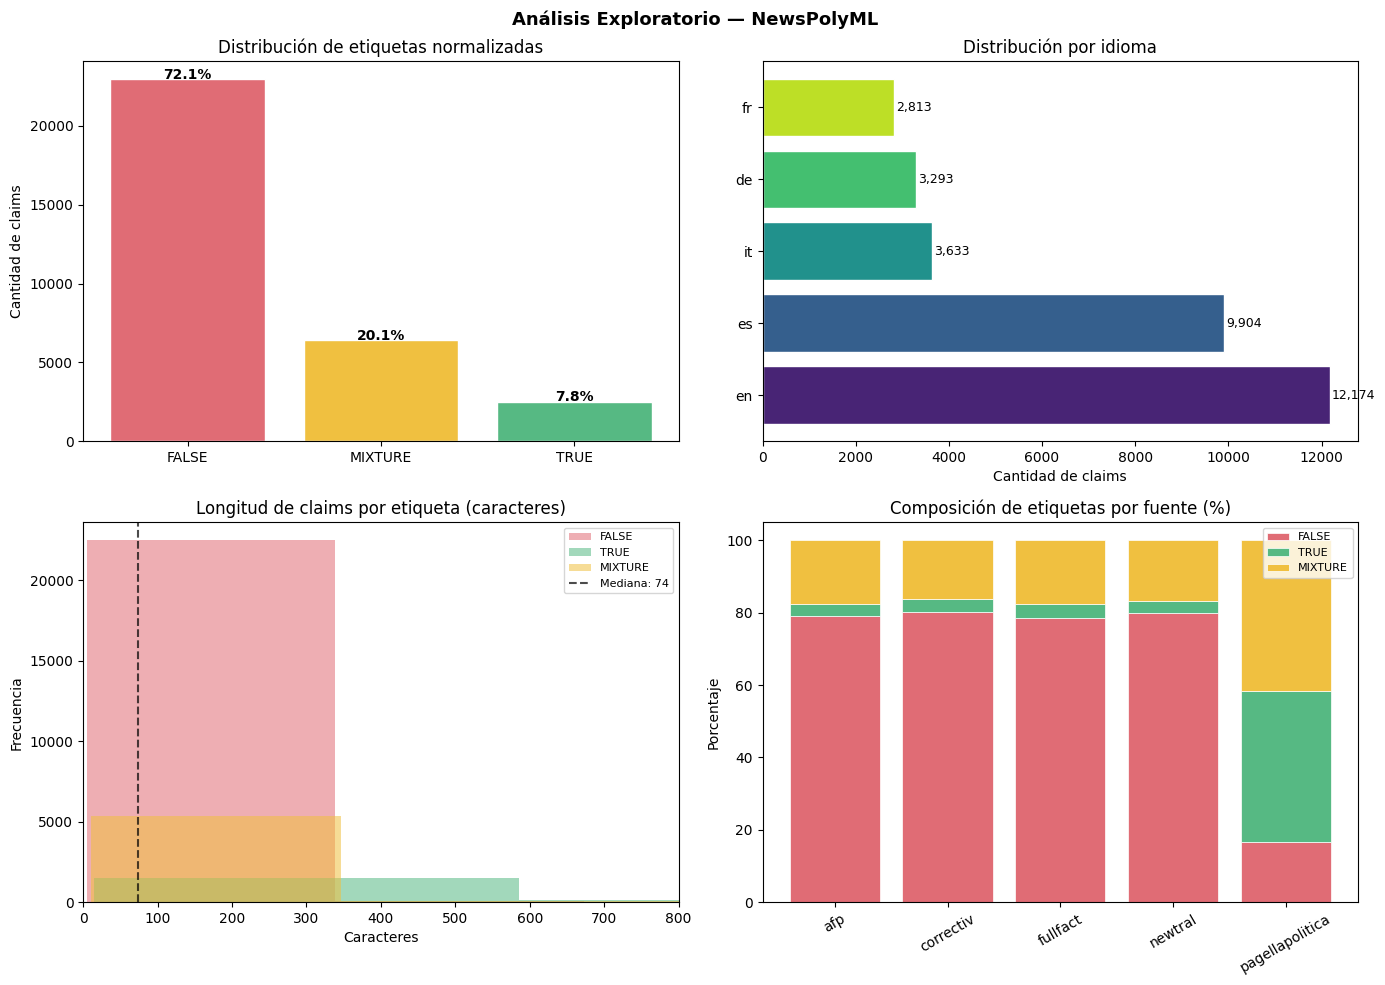

In [7]:
LABEL_COLORS = {
    'FALSE':   '#e06c75',
    'TRUE':    '#56b983',
    'MIXTURE': '#f0c040',
    'OTHER':   '#8888cc',
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Análisis Exploratorio — NewsPolyML', fontsize=13, fontweight='bold')

# 1. Distribución de etiquetas
vc = df['label'].value_counts()
bars = axes[0,0].bar(vc.index, vc.values,
                     color=[LABEL_COLORS[l] for l in vc.index], edgecolor='white')
axes[0,0].set_title('Distribución de etiquetas normalizadas')
axes[0,0].set_ylabel('Cantidad de claims')
for bar, val in zip(bars, vc.values):
    pct = 100 * val / len(df)
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                   f'{pct:.1f}%', ha='center', fontsize=10, fontweight='bold')

# 2. Distribución por idioma
lang_vc = df['lang'].value_counts()
lang_colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(lang_vc)))
axes[0,1].barh(lang_vc.index, lang_vc.values, color=lang_colors, edgecolor='white')
axes[0,1].set_title('Distribución por idioma')
axes[0,1].set_xlabel('Cantidad de claims')
for i, val in enumerate(lang_vc.values):
    axes[0,1].text(val + 50, i, f'{val:,}', va='center', fontsize=9)

# 3. Histograma de longitudes por etiqueta
for lbl, color in LABEL_COLORS.items():
    subset = df[df['label'] == lbl]['char_len']
    if len(subset) > 0:
        axes[1,0].hist(subset, bins=40, alpha=0.55, label=lbl, color=color)
axes[1,0].set_title('Longitud de claims por etiqueta (caracteres)')
axes[1,0].set_xlabel('Caracteres')
axes[1,0].set_ylabel('Frecuencia')
axes[1,0].set_xlim(0, 800)
axes[1,0].axvline(df['char_len'].median(), color='black', linestyle='--', alpha=0.7,
                  label=f"Mediana: {df['char_len'].median():.0f}")
axes[1,0].legend(fontsize=8)

# 4. Etiquetas por fuente
source_label = df.groupby(['source','label']).size().unstack(fill_value=0)
source_label_pct = source_label.div(source_label.sum(axis=1), axis=0) * 100
bottom = np.zeros(len(source_label_pct))
for lbl, color in LABEL_COLORS.items():
    if lbl in source_label_pct.columns:
        vals = source_label_pct[lbl].values
        axes[1,1].bar(source_label_pct.index, vals, bottom=bottom,
                      label=lbl, color=color, edgecolor='white', linewidth=0.5)
        bottom += vals
axes[1,1].set_title('Composición de etiquetas por fuente (%)')
axes[1,1].set_ylabel('Porcentaje')
axes[1,1].tick_params(axis='x', rotation=30)
axes[1,1].legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig('eda_newspolyml.png', dpi=120, bbox_inches='tight')
plt.show()



###Hallazgos del EDA:
En el subconjunto español el desequilibrio es 79.5% FALSE (vs 71.4% global). Esto hace el problema aún más difícil que lo descrito en el paper.

Mediana de 74 caracteres: mucho más corto que los 286 chars del promedio global reportado en el README. Los claims de AFP y Newtral en español son particularmente concisos — max_len=128 fue una elección acertada.

Pagella Politica (italiano) es la única fuente con composición distinta: casi 40% TRUE, lo que explica por qué el modelo multilingüe rendiría diferente al monolingüe.

AFP y Newtral dominan en español: ~57% AFP, ~43% Newtral. Vale la pena anotar que estas dos agencias pueden tener estilos de redacción distintos en sus claims.

### 1.2 Experimento: solo español

Para mantenernos alineados con el alcance del notebook guía (clasificación de texto en español), entrenamos primero solo con los claims en español. Esto también evita que el tokenizador deba cubrir 5 idiomas simultáneamente con un vocabulario pequeño.

Si el tiempo lo permite, al final comentamos qué cambiaría para el experimento multilingüe.

In [8]:
# Filtrar español
# Los idiomas en este dataset vienen como 'es', 'en', 'de', etc. (ISO 639-1)
ES_CODES = {'es'}
df_es = df[df['lang'].str.lower().isin(ES_CODES)].copy().reset_index(drop=True)

print(f'Claims en español: {len(df_es):,}')
print('\nDistribución de etiquetas (español):')
vc_es = df_es['label'].value_counts()
for lbl, cnt in vc_es.items():
    print(f'  {lbl:10s}: {cnt:6,} ({100*cnt/len(df_es):.1f}%)')
print('\nFuentes en español:')
print(df_es['source'].value_counts().to_string())

Claims en español: 9,904

Distribución de etiquetas (español):
  FALSE     :  7,878 (79.5%)
  MIXTURE   :  1,701 (17.2%)
  TRUE      :    325 (3.3%)

Fuentes en español:
source
afp        5676
newtral    4228


## 2. Tokenizer entrenado en el corpus

Entrenamos un tokenizador BPE sobre los claims en español. A diferencia del notebook guía (noticias con ~4200 chars), nuestros claims tienen ~286 chars en promedio. Implicaciones:
- Vocabulario más pequeño (20K tokens suficientes).
- El tokenizador debe capturar terminología de fact-checking: nombres propios, siglas, fechas, URLs parciales.

In [9]:
from tqdm.auto import tqdm
from transformers import AutoTokenizer
from transformers.models.gpt2.tokenization_gpt2 import bytes_to_unicode

all_texts = df_es['text'].tolist()
print(f'Textos para entrenar el tokenizador: {len(all_texts):,}')
print(f'Longitud media: {np.mean([len(t) for t in all_texts]):.1f} chars')

base_tokenizer = AutoTokenizer.from_pretrained('gpt2')
byte_to_unicode_map = bytes_to_unicode()
unicode_to_byte_map = dict((v, k) for k, v in byte_to_unicode_map.items())
base_vocab = list(unicode_to_byte_map.keys())

def batch_iterator(texts, batch_size=32):
    for i in tqdm(range(0, len(texts), batch_size)):
        yield texts[i:i + batch_size]

# 20K tokens: adecuado para claims cortos en español
# El guía usa 50K para ~10K artículos de noticias completos
newspolyml_tokenizer = base_tokenizer.train_new_from_iterator(
    batch_iterator(all_texts),
    vocab_size=20000,
    initial_alphabet=base_vocab
)
newspolyml_tokenizer.pad_token = '[PAD]'
print(f'\nVocabulario entrenado: {newspolyml_tokenizer.vocab_size:,} tokens')

Textos para entrenar el tokenizador: 9,904
Longitud media: 93.7 chars


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

  0%|          | 0/310 [00:00<?, ?it/s]


Vocabulario entrenado: 20,000 tokens


In [10]:
tokens_sorted = sorted(newspolyml_tokenizer.vocab.items(), key=lambda x: x[1])

print('Primeros 15 tokens (caracteres base):')
print([newspolyml_tokenizer.convert_tokens_to_string([t]) for t, _ in tokens_sorted[:15]])

print('\nTokens del medio (palabras frecuentes de claims):')
print([newspolyml_tokenizer.convert_tokens_to_string([t]) for t, _ in tokens_sorted[500:515]])

print('\nÚltimos 15 tokens (términos especializados / raros):')
print([newspolyml_tokenizer.convert_tokens_to_string([t]) for t, _ in tokens_sorted[-15:]])

Primeros 15 tokens (caracteres base):
['<|endoftext|>', '!', '"', '#', '$', '%', '&', "'", '(', ')', '*', '+', ',', '-', '.']

Tokens del medio (palabras frecuentes de claims):
['obierno', 'ul', ' to', 'ab', 'obre', ' ni', ' U', 'das', ' “', ' vídeo', ' le', 'En', 'den', ' pu', 'ista']

Últimos 15 tokens (términos especializados / raros):
['onardo', 'onizaron', 'onny', 'onkis', 'online', 'ontólogos', 'onhy', 'tam', 'tay', 'tare', 'taque', 'tari', 'tamen', 'tamo', 'taño']


In [11]:
# Explorar tokenización de claims representativos
ejemplos = [
    ('La vacuna contra el COVID-19 causa infertilidad', 'FALSE'),
    ('El presidente firmó el decreto el 15 de marzo de 2023', 'TRUE'),
    ('La inflación subió pero también bajaron ciertos precios', 'MIXTURE'),
]

print('Tokenización de claims representativos:')
print('-' * 65)
for txt, lbl in ejemplos:
    ids  = newspolyml_tokenizer(txt)['input_ids']
    toks = [newspolyml_tokenizer.decode([i]) for i in ids]
    print(f'Etiqueta : {lbl}')
    print(f'Claim    : {txt}')
    print(f'Tokens ({len(toks)}): {toks}')
    print()

print("""
Observación: A diferencia de un tokenizador de noticias formales, el nuestro
entrenado en claims captura mejor:
- Nombres propios y siglas (COVID-19, OMS, etc.)
- Fechas y cifras (comunes en claims verificables)
- Verbos de atribución ('afirmó', 'declaró') frecuentes en fact-checking
""")

Tokenización de claims representativos:
-----------------------------------------------------------------
Etiqueta : FALSE
Claim    : La vacuna contra el COVID-19 causa infertilidad
Tokens (9): ['La', ' vacuna', ' contra', ' el', ' COVID', '-', '19', ' causa', ' infertilidad']

Etiqueta : TRUE
Claim    : El presidente firmó el decreto el 15 de marzo de 2023
Tokens (11): ['El', ' presidente', ' firmó', ' el', ' decreto', ' el', ' 15', ' de', ' marzo', ' de', ' 2023']

Etiqueta : MIXTURE
Claim    : La inflación subió pero también bajaron ciertos precios
Tokens (9): ['La', ' inflación', ' subió', ' pero', ' también', ' bajaron', ' cier', 'tos', ' precios']


Observación: A diferencia de un tokenizador de noticias formales, el nuestro
entrenado en claims captura mejor:
- Nombres propios y siglas (COVID-19, OMS, etc.)
- Fechas y cifras (comunes en claims verificables)
- Verbos de atribución ('afirmó', 'declaró') frecuentes en fact-checking



## 3. Dataset de PyTorch

Usamos los claims en español. Dado que el dataset no viene con splits predefinidos, hacemos una división 70/15/15 estratificada por etiqueta para mantener la proporción de clases en cada split.

In [12]:
import torch
import torch.nn as nn
from typing import Dict
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

MAX_LEN   = 128   # Suficiente para claims (~286 chars → ~60-80 tokens)
EMB_DIM   = 128
NUM_HEADS = 8
BATCH_SIZE = 32


class NewsPolyMLDataset(Dataset):
    """Dataset de claims de fact-checking para detección de desinformación.

    Notas de diseño:
    - seq_length = 128: los claims tienen ~60-80 tokens en promedio.
      Usar 2048 (como el guía para noticias completas) sería un despilfarro.
    - Las 4 etiquetas ya están normalizadas por Mixtral, por lo que no
      necesitamos limpieza adicional de labels.
    """

    def __init__(self, tokenizer, texts, labels, seq_length=128):
        self.tokenizer  = tokenizer
        self.texts      = texts
        self.labels     = labels
        self.seq_length = seq_length

        unique = sorted(set(labels))
        self.id_2_class = dict(enumerate(unique))
        self.class_2_id = {v: k for k, v in self.id_2_class.items()}
        self.num_classes = len(unique)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx) -> Dict[str, torch.Tensor]:
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.seq_length,
            truncation=True,
            padding='max_length'
        )
        data = {k: torch.tensor(v) for k, v in enc.items()}
        data['y'] = torch.tensor(self.class_2_id[self.labels[idx]], dtype=torch.long)
        return data


# Split estratificado 70 / 15 / 15
texts_all  = df_es['text'].tolist()
labels_all = df_es['label'].tolist()

X_train, X_temp, y_train, y_temp = train_test_split(
    texts_all, labels_all, test_size=0.30,
    stratify=labels_all, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50,
    stratify=y_temp, random_state=42
)

train_ds = NewsPolyMLDataset(newspolyml_tokenizer, X_train, y_train, seq_length=MAX_LEN)
val_ds   = NewsPolyMLDataset(newspolyml_tokenizer, X_val,   y_val,   seq_length=MAX_LEN)
test_ds  = NewsPolyMLDataset(newspolyml_tokenizer, X_test,  y_test,  seq_length=MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Clases: {train_ds.id_2_class}')
print(f'Train: {len(train_ds):,} | Val: {len(val_ds):,} | Test: {len(test_ds):,}')

Clases: {0: 'FALSE', 1: 'MIXTURE', 2: 'TRUE'}
Train: 6,932 | Val: 1,486 | Test: 1,486


### 3.1 Pesos de clase para el desbalance

In [13]:
from collections import Counter

label_counts = Counter(y_train)
n_total      = len(y_train)
num_classes  = train_ds.num_classes


class_weights = torch.zeros(train_ds.num_classes)
manual_weights = {'FALSE': 1.0, 'MIXTURE': 4.0, 'TRUE': 6.0}

for cls_str, w in manual_weights.items():
    if cls_str in train_ds.class_2_id:
        class_weights[train_ds.class_2_id[cls_str]] = w

print('Pesos manuales:', {k: v for k, v in zip(manual_weights.keys(), class_weights.tolist())})

print("""
La clase FALSE, al ser la mayoritaria (~71%), recibe el menor peso.
Las clases TRUE, MIXTURE y OTHER reciben pesos mayores para compensar
su menor representación y que el modelo no ignore estas clases.
""")

Pesos manuales: {'FALSE': 1.0, 'MIXTURE': 4.0, 'TRUE': 6.0}

La clase FALSE, al ser la mayoritaria (~71%), recibe el menor peso.
Las clases TRUE, MIXTURE y OTHER reciben pesos mayores para compensar
su menor representación y que el modelo no ignore estas clases.



## 4. Arquitectura del Transformer

### 4.1 Token + Positional Embedding

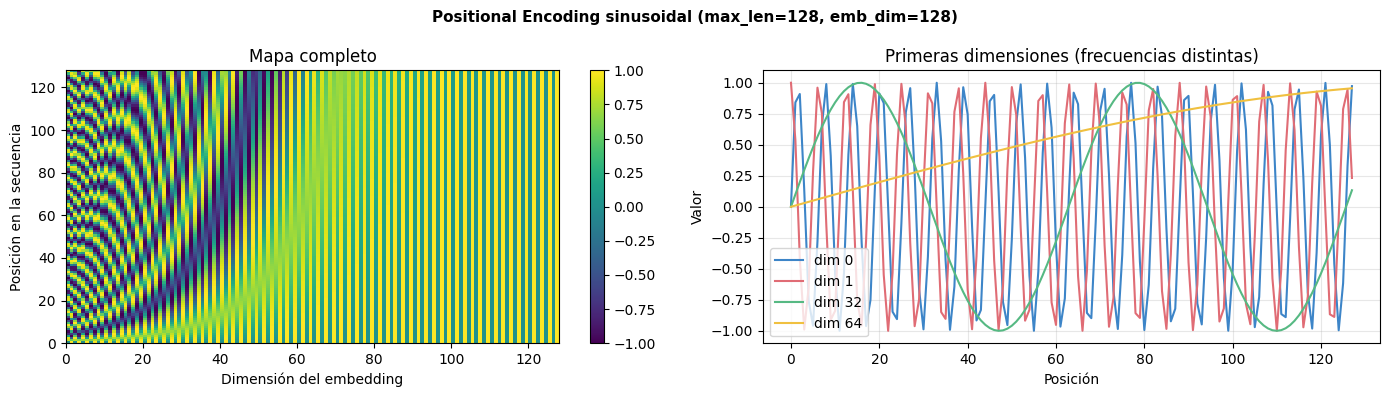

In [14]:
import math


class TokenAndPosEmbedding(nn.Module):
    """Embedding de tokens con positional encoding sinusoidal fijo.

    El positional encoding NO es aprendido. Usa la fórmula de
    'Attention is All You Need' (Vaswani et al., 2017):

        PE(pos, 2i)   = sin(pos / 10000^(2i / d_model))
        PE(pos, 2i+1) = cos(pos / 10000^(2i / d_model))

    Esto permite distinguir de forma única cada posición dentro
    de la secuencia sin añadir parámetros entrenables.
    """

    def __init__(self, max_len: int, emb_dim: int, vocab_size: int):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, emb_dim, padding_idx=0)

        pe  = torch.zeros(max_len, emb_dim)
        pos = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div = torch.exp(
            torch.arange(0, emb_dim, 2, dtype=torch.float)
            * (-math.log(10000.0) / emb_dim)
        )
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))  # (1, max_len, emb_dim)

    def forward(self, x):
        return self.token_emb(x) + self.pe[:, :x.size(1), :]


# Visualización
tpe_test  = TokenAndPosEmbedding(MAX_LEN, EMB_DIM, newspolyml_tokenizer.vocab_size)
pe_matrix = tpe_test.pe.squeeze(0).detach().numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Positional Encoding sinusoidal (max_len=128, emb_dim=128)',
             fontsize=11, fontweight='bold')

im = axes[0].pcolormesh(pe_matrix, cmap='viridis')
axes[0].set_xlabel('Dimensión del embedding')
axes[0].set_ylabel('Posición en la secuencia')
axes[0].set_title('Mapa completo')
plt.colorbar(im, ax=axes[0])

for i, color in zip([0, 1, 32, 64], ['#3d85c8','#e06c75','#56b983','#f0c040']):

    axes[1].plot(pe_matrix[:, i], label=f'dim {i}', color=color)
axes[1].set_xlabel('Posición')
axes[1].set_ylabel('Valor')
axes[1].set_title('Primeras dimensiones (frecuencias distintas)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('positional_encoding.png', dpi=120, bbox_inches='tight')
plt.show()

### 4.2 Multi-Head Attention

$$\text{Attention}(Q,K,V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_K}}\right)V$$

In [15]:
class MultiHeadAttention(nn.Module):

    def __init__(self, embed_size: int, num_heads: int = 8):
        super().__init__()
        assert embed_size % num_heads == 0
        self.embed_size     = embed_size
        self.num_heads      = num_heads
        self.projection_dim = embed_size // num_heads

        self.W_q = nn.Linear(embed_size, embed_size, bias=False)
        self.W_k = nn.Linear(embed_size, embed_size, bias=False)
        self.W_v = nn.Linear(embed_size, embed_size, bias=False)
        self.W_o = nn.Linear(embed_size, embed_size)

    @staticmethod
    def _scaled_dot_product(q, k, v, mask=None):
        """Scaled dot-product attention con máscara de padding.

        La máscara evita que el modelo preste atención a los tokens [PAD],
        que no aportan información semántica. Los tokens enmascarados
        reciben un logit de -9e15 que, tras el softmax, resulta en ~0.
        """
        d_k         = q.size(-1)
        attn_logits = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)

        if mask is not None:
            attn_logits = attn_logits.masked_fill(
                mask.reshape(mask.shape[0], 1, 1, -1) == 0, -9e15
            )
        attention = torch.softmax(attn_logits, dim=-1)
        values    = torch.matmul(attention, v)
        return values, attention

    def _split_heads(self, x, batch_size):
        x = x.reshape(batch_size, -1, self.num_heads, self.projection_dim)
        return x.permute(0, 2, 1, 3)  # (B, heads, T, proj)

    def forward(self, x, mask=None, return_attention=False):
        B, T, C = x.size()
        q = self._split_heads(self.W_q(x), B)
        k = self._split_heads(self.W_k(x), B)
        v = self._split_heads(self.W_v(x), B)

        out, attn_w = self._scaled_dot_product(q, k, v, mask)
        out = out.permute(0, 2, 1, 3).reshape(B, T, C)
        out = self.W_o(out)

        return (out, attn_w) if return_attention else out


# Verificación
dummy_ids = torch.randint(0, newspolyml_tokenizer.vocab_size, (4, MAX_LEN))
dummy_emb = tpe_test(dummy_ids)
mha       = MultiHeadAttention(EMB_DIM, NUM_HEADS)
out_mha, attn_w = mha(dummy_emb, return_attention=True)
print(f'Input embedding   : {dummy_emb.shape}')
print(f'MHA output        : {out_mha.shape}')
print(f'Attention weights : {attn_w.shape}  → (batch, heads, seq, seq)')

Input embedding   : torch.Size([4, 128, 128])
MHA output        : torch.Size([4, 128, 128])
Attention weights : torch.Size([4, 8, 128, 128])  → (batch, heads, seq, seq)


### 4.3 Bloque Transformer (Encoder)

In [16]:
class TransformerBlock(nn.Module):
    """Encoder block con conexiones residuales y Layer Normalization.

    Diferencias respecto al notebook guía:
    1. Conexiones residuales (x + sublayer(x)): parte esencial de la
       arquitectura original (Vaswani et al., 2017) que estabilizan
       los gradientes en entrenamiento profundo.
    2. Pre-LN: la normalización se aplica ANTES de cada sublayer
       (más estable numéricamente que Post-LN del paper original).
    3. GELU en lugar de ReLU en el FFN.
    """

    def __init__(self, emb_dim: int, num_heads: int = 8,
                 ffn_dim: int = 256, dropout: float = 0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(emb_dim)
        self.mhatt = MultiHeadAttention(emb_dim, num_heads)
        self.drop1 = nn.Dropout(dropout)

        self.norm2 = nn.LayerNorm(emb_dim)
        self.ffn   = nn.Sequential(
            nn.Linear(emb_dim, ffn_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ffn_dim, emb_dim)
        )
        self.drop2 = nn.Dropout(dropout)

    def forward(self, x, mask=None, return_attention=False):
        normed = self.norm1(x)
        if return_attention:
            attn_out, attn_w = self.mhatt(normed, mask, return_attention=True)
        else:
            attn_out = self.mhatt(normed, mask)
        x = x + self.drop1(attn_out)           # residual 1
        x = x + self.drop2(self.ffn(self.norm2(x)))  # residual 2

        return (x, attn_w) if return_attention else x


tb_test = TransformerBlock(EMB_DIM, NUM_HEADS)
print(f'TransformerBlock output: {tb_test(dummy_emb).shape}  ✓')

TransformerBlock output: torch.Size([4, 128, 128])  ✓


### 4.4 Clasificador completo

**Decisión de pooling:** usamos **Global Average Pooling enmascarado** en lugar de `Flatten` (como en el guía).

Con `Flatten`, `max_len=128` y `emb_dim=128` generaríamos un vector de 16.384 dimensiones → capa lineal masiva para un corpus relativamente pequeño. Con Average Pooling: vector de 128 dimensiones, independiente de `max_len`, e ignorando tokens de padding.

In [17]:
import torch.nn.functional as F
import glob
from lightning import LightningModule, Trainer
from lightning.pytorch.loggers import CSVLogger
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from torchmetrics import Accuracy, F1Score


class NewsPolyMLClassifier(LightningModule):
    """Clasificador de veracidad de claims periodísticos.

    Arquitectura:
        TokenAndPosEmbedding → TransformerBlock → Masked Avg Pool → MLP

    El masked average pooling promedia solo las posiciones reales del claim
    (ignorando padding), produciendo un vector de tamaño emb_dim.
    """

    def __init__(self, max_len, vocab_size, num_classes, emb_dim,
                 num_heads=8, class_weights=None):
        super().__init__()
        self.save_hyperparameters(ignore=['class_weights'])
        self.num_classes   = num_classes
        self.class_weights = class_weights

        self.embeddings  = TokenAndPosEmbedding(max_len, emb_dim, vocab_size)
        self.transformer = TransformerBlock(emb_dim, num_heads)
        self.classifier = nn.Sequential(
            nn.Linear(emb_dim, 256),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

        self.train_acc = Accuracy(task='multiclass', num_classes=num_classes)
        self.val_acc   = Accuracy(task='multiclass', num_classes=num_classes)
        self.test_acc  = Accuracy(task='multiclass', num_classes=num_classes)
        self.val_f1    = F1Score(task='multiclass', num_classes=num_classes, average='macro')
        self.test_f1   = F1Score(task='multiclass', num_classes=num_classes, average='macro')

    def _masked_avg_pool(self, x, mask):
        mask_f = mask.unsqueeze(-1).float()
        return (x * mask_f).sum(dim=1) / mask_f.sum(dim=1).clamp(min=1)

    def forward(self, x, mask=None, return_attention=False):
        emb = self.embeddings(x)
        if return_attention:
            out, attn = self.transformer(emb, mask, return_attention=True)
        else:
            out = self.transformer(emb, mask)

        pooled = self._masked_avg_pool(out, mask) if mask is not None else out.mean(dim=1)
        logits = self.classifier(pooled)

        return (logits, attn) if return_attention else logits

    def _loss(self, y_hat, y):
        w = self.class_weights.to(self.device) if self.class_weights is not None else None
        return F.cross_entropy(y_hat, y, weight=w)

    def training_step(self, batch):
        x, mask, y = batch['input_ids'], batch['attention_mask'], batch['y']
        y_hat = self(x, mask)
        loss  = self._loss(y_hat, y)
        self.train_acc(y_hat, y)
        self.log('train_loss', loss,           prog_bar=True, on_epoch=True, on_step=False)
        self.log('train_acc',  self.train_acc, prog_bar=True, on_epoch=True, on_step=False)
        return loss

    def validation_step(self, batch):
        x, mask, y = batch['input_ids'], batch['attention_mask'], batch['y']
        y_hat = self(x, mask)
        loss  = self._loss(y_hat, y)
        self.val_acc(y_hat, y)
        self.val_f1(y_hat, y)
        self.log('val_loss', loss,         prog_bar=True, on_epoch=True, on_step=False)
        self.log('val_acc',  self.val_acc, prog_bar=True, on_epoch=True, on_step=False)
        self.log('val_f1',   self.val_f1,  prog_bar=True, on_epoch=True, on_step=False)

    def test_step(self, batch):
        x, mask, y = batch['input_ids'], batch['attention_mask'], batch['y']
        y_hat = self(x, mask)
        self.test_acc(y_hat, y)
        self.test_f1(y_hat, y)
        self.log('test_acc', self.test_acc, on_epoch=True, on_step=False)
        self.log('test_f1',  self.test_f1,  on_epoch=True, on_step=False)

    def configure_optimizers(self):

        opt = torch.optim.AdamW(self.parameters(), lr=3e-5, weight_decay=5e-3)
        sch = torch.optim.lr_scheduler.OneCycleLR(
            opt, max_lr=5e-5,
            steps_per_epoch=len(train_loader),
            epochs=20, pct_start=0.1
        )
        return {'optimizer': opt, 'lr_scheduler': {'scheduler': sch, 'interval': 'step'}}


model = NewsPolyMLClassifier(
    max_len=MAX_LEN,
    vocab_size=newspolyml_tokenizer.vocab_size,
    num_classes=train_ds.num_classes,
    emb_dim=EMB_DIM,
    num_heads=NUM_HEADS,
    class_weights=class_weights
)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parámetros entrenables: {total_params:,}')
print('(El guía tiene ~140M con Flatten. Aquí usamos Global Avg Pool → ~3M)')

Parámetros entrenables: 2,758,403
(El guía tiene ~140M con Flatten. Aquí usamos Global Avg Pool → ~3M)


## 5. Entrenamiento

In [18]:
import shutil, os
if os.path.exists('logs/NewsPolyML'):
    shutil.rmtree('logs/NewsPolyML')

accelerator = 'gpu' if torch.cuda.is_available() else 'cpu'
print(f'Dispositivo: {accelerator.upper()}')

csv_logger = CSVLogger('logs', name='NewsPolyML')

callbacks = [
    EarlyStopping(monitor='val_f1', patience=8, mode='max',
                  min_delta=0.005, verbose=True),
    ModelCheckpoint(
        monitor='val_f1', mode='max',
        filename='best_model', save_top_k=1, verbose=True
    )
]

trainer = Trainer(
    max_epochs=20,
    accelerator=accelerator,
    devices=1,
    logger=csv_logger,
    callbacks=callbacks,
    precision='16-mixed' if accelerator == 'gpu' else 32
)

trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)

INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Dispositivo: CPU


┏━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name        ┃ Type                 ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ embeddings  │ TokenAndPosEmbedding │  2.6 M │ train │     0 │
│ 1 │ transformer │ TransformerBlock     │  132 K │ train │     0 │
│ 2 │ classifier  │ Sequential           │ 66.3 K │ train │     0 │
│ 3 │ train_acc   │ MulticlassAccuracy   │      0 │ train │     0 │
│ 4 │ val_acc     │ MulticlassAccuracy   │      0 │ train │     0 │
│ 5 │ test_acc    │ MulticlassAccuracy   │      0 │ train │     0 │
│ 6 │ val_f1      │ MulticlassF1Score    │      0 │ train │     0 │
│ 7 │ test_f1     │ MulticlassF1Score    │      0 │ train │     0 │
└───┴─────────────┴──────────────────────┴────────┴───────┴───────┘

Trainable params: 2.8 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.8 M                                                                                                
Total estimated model params size (MB): 11                                                                         
Modules in train mode: 30                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO: Metric val_f1 improved. New best score: 0.295
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_f1 improved. New best score: 0.295
INFO: Epoch 0, global step 217: 'val_f1' reached 0.29535 (best 0.29535), saving model to 'logs/NewsPolyML/version_0/checkpoints/best_model.ckpt' as top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 0, global step 217: 'val_f1' reached 0.29535 (best 0.29535), saving model to 'logs/NewsPolyML/version_0/checkpoints/best_model.ckpt' as top 1
INFO: Epoch 1, global step 434: 'val_f1' was not in top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 1, global step 434: 'val_f1' was not in top 1
INFO: Epoch 2, global step 651: 'val_f1' was not in top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 2, global step 651: 'val_f1' was not in top 1
INFO: Epoch 3, global step 868: 'val_f1' was not in top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 3, global step 868: 'val_f1' was not in top 1
INFO: Epoch 4, global step 1085: 'val_f1' was not 

## 6. Curvas de entrenamiento

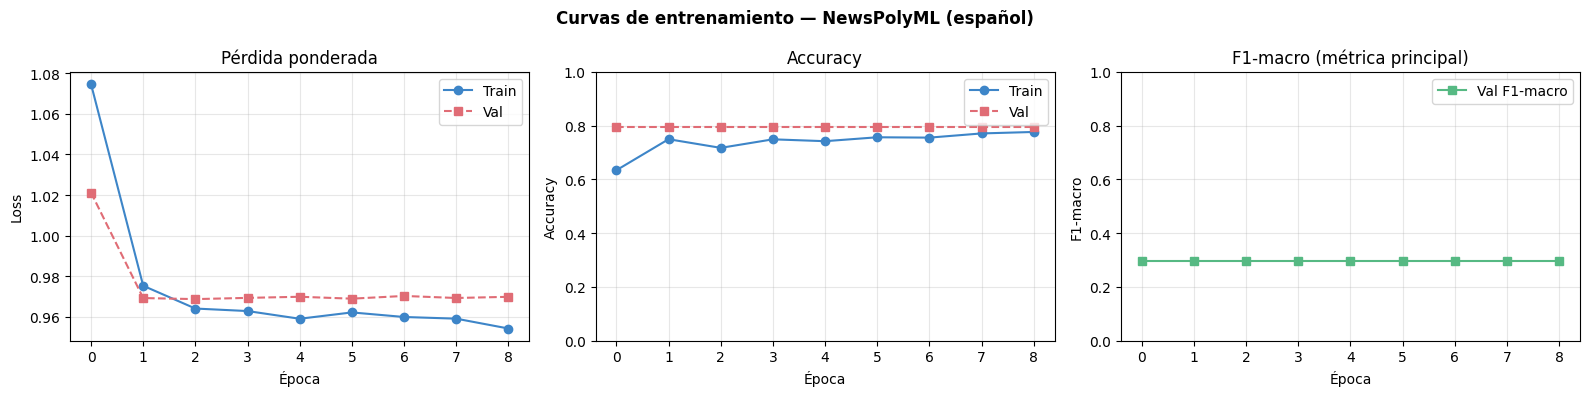


Clave: Con clases tan desbalanceadas (71% FALSE), la accuracy puede
mantenerse alta aunque el modelo nunca aprenda a detectar TRUE o MIXTURE.
El F1-macro castiga ese comportamiento al promediar el F1 de cada clase
con igual peso, independiente de su frecuencia.



In [25]:
csv_files = glob.glob('logs/NewsPolyML/**/metrics.csv', recursive=True)
assert csv_files, 'No se encontró el archivo de métricas.'
metrics = pd.read_csv(sorted(csv_files)[-1])

train_m = metrics.dropna(subset=['train_loss']).groupby('epoch').mean(numeric_only=True)
val_m   = metrics.dropna(subset=['val_loss']).groupby('epoch').mean(numeric_only=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Curvas de entrenamiento — NewsPolyML (español)',
             fontsize=12, fontweight='bold')

# Pérdida
axes[0].plot(train_m.index, train_m['train_loss'], 'o-', color='#3d85c8', label='Train')
axes[0].plot(val_m.index,   val_m['val_loss'],     's--', color='#e06c75', label='Val')
axes[0].set_title('Pérdida ponderada')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(train_m.index, train_m['train_acc'], 'o-', color='#3d85c8', label='Train')
axes[1].plot(val_m.index,   val_m['val_acc'],     's--', color='#e06c75', label='Val')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1); axes[1].legend(); axes[1].grid(alpha=0.3)

# F1-macro
axes[2].plot(val_m.index, val_m['val_f1'], 's-', color='#56b983', label='Val F1-macro')
axes[2].set_title('F1-macro (métrica principal)')
axes[2].set_xlabel('Época'); axes[2].set_ylabel('F1-macro')
axes[2].set_ylim(0, 1); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('curvas_entrenamiento.png', dpi=120, bbox_inches='tight')
plt.show()

print("""
Clave: Con clases tan desbalanceadas (71% FALSE), la accuracy puede
mantenerse alta aunque el modelo nunca aprenda a detectar TRUE o MIXTURE.
El F1-macro castiga ese comportamiento al promediar el F1 de cada clase
con igual peso, independiente de su frecuencia.
""")

## 7. Evaluación en el conjunto de prueba

In [26]:
from sklearn.metrics import confusion_matrix, classification_report

# Cargar mejor checkpoint
ckpts = glob.glob('logs/NewsPolyML/**/best_model*.ckpt', recursive=True)
if ckpts:
    model = NewsPolyMLClassifier.load_from_checkpoint(
        sorted(ckpts)[-1], class_weights=class_weights
    )
    print(f'Checkpoint cargado: {sorted(ckpts)[-1]}')

results = trainer.test(model, dataloaders=test_loader)
print(f'\nTest Accuracy : {results[0]["test_acc"]:.4f}')
print(f'Test F1-macro : {results[0]["test_f1"]:.4f}')

Checkpoint cargado: logs/NewsPolyML/version_0/checkpoints/best_model.ckpt


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.7954239845275879     │
│          test_f1          │    0.2953523099422455     │
└───────────────────────────┴───────────────────────────┘


Test Accuracy : 0.7954
Test F1-macro : 0.2954


In [27]:
# Predicciones completas
model.eval()
device = next(model.parameters()).device
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        x, mask, y = (batch['input_ids'].to(device),
                      batch['attention_mask'].to(device),
                      batch['y'])
        preds = model(x, mask).argmax(dim=-1).cpu()
        all_preds.append(preds)
        all_labels.append(y)

all_preds  = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()
class_names = [train_ds.id_2_class[i] for i in range(train_ds.num_classes)]

print('=== Reporte de clasificación ===')
print(classification_report(all_labels, all_preds, target_names=class_names))

=== Reporte de clasificación ===
              precision    recall  f1-score   support

       FALSE       0.80      1.00      0.89      1182
     MIXTURE       0.00      0.00      0.00       255
        TRUE       0.00      0.00      0.00        49

    accuracy                           0.80      1486
   macro avg       0.27      0.33      0.30      1486
weighted avg       0.63      0.80      0.70      1486



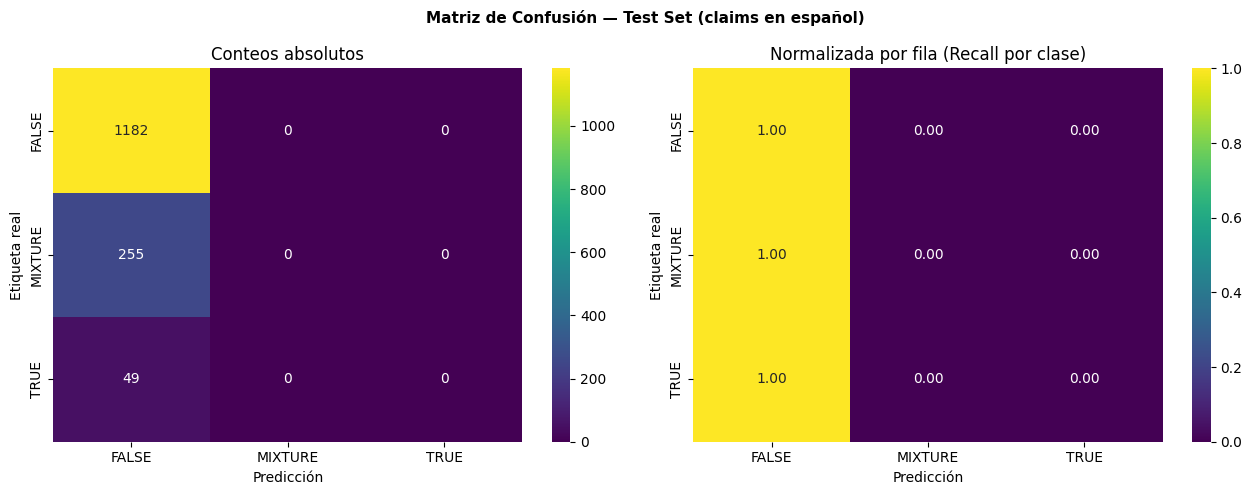


La normalización por fila muestra el recall de cada clase: qué fracción
de los claims verdaderamente FALSE/TRUE/MIXTURE/OTHER clasifica correctamente.
Con desbalance, es común ver recall alto en FALSE y bajo en las demás.



In [28]:
cm     = confusion_matrix(all_labels, all_preds)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Matriz de Confusión — Test Set (claims en español)',
             fontsize=11, fontweight='bold')

sns.heatmap(cm, annot=True, fmt='d', cmap='viridis',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_xlabel('Predicción'); axes[0].set_ylabel('Etiqueta real')
axes[0].set_title('Conteos absolutos')

sns.heatmap(cm_pct, annot=True, fmt='.2f', cmap='viridis', vmin=0, vmax=1,
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_xlabel('Predicción'); axes[1].set_ylabel('Etiqueta real')
axes[1].set_title('Normalizada por fila (Recall por clase)')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()



## 8. Visualización de Pesos de Atención

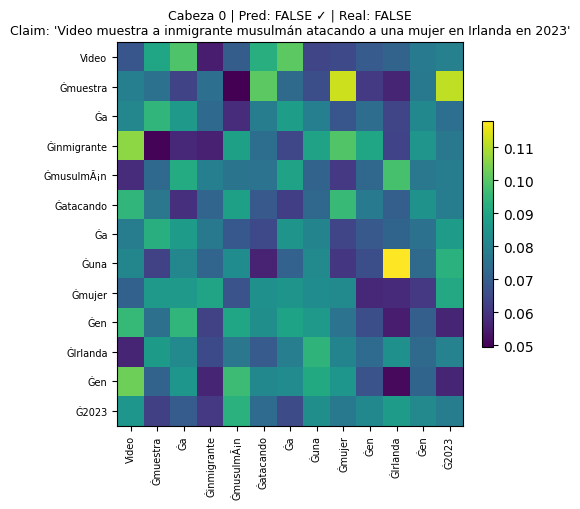

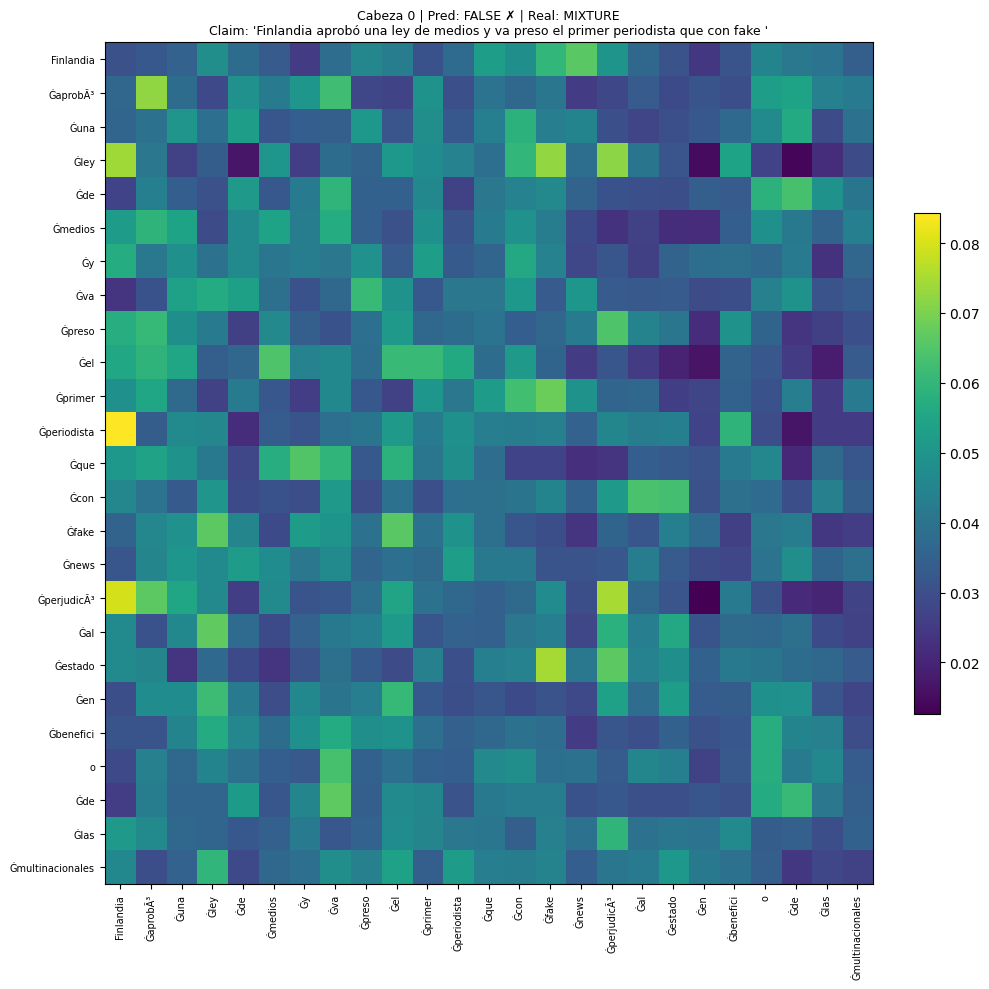

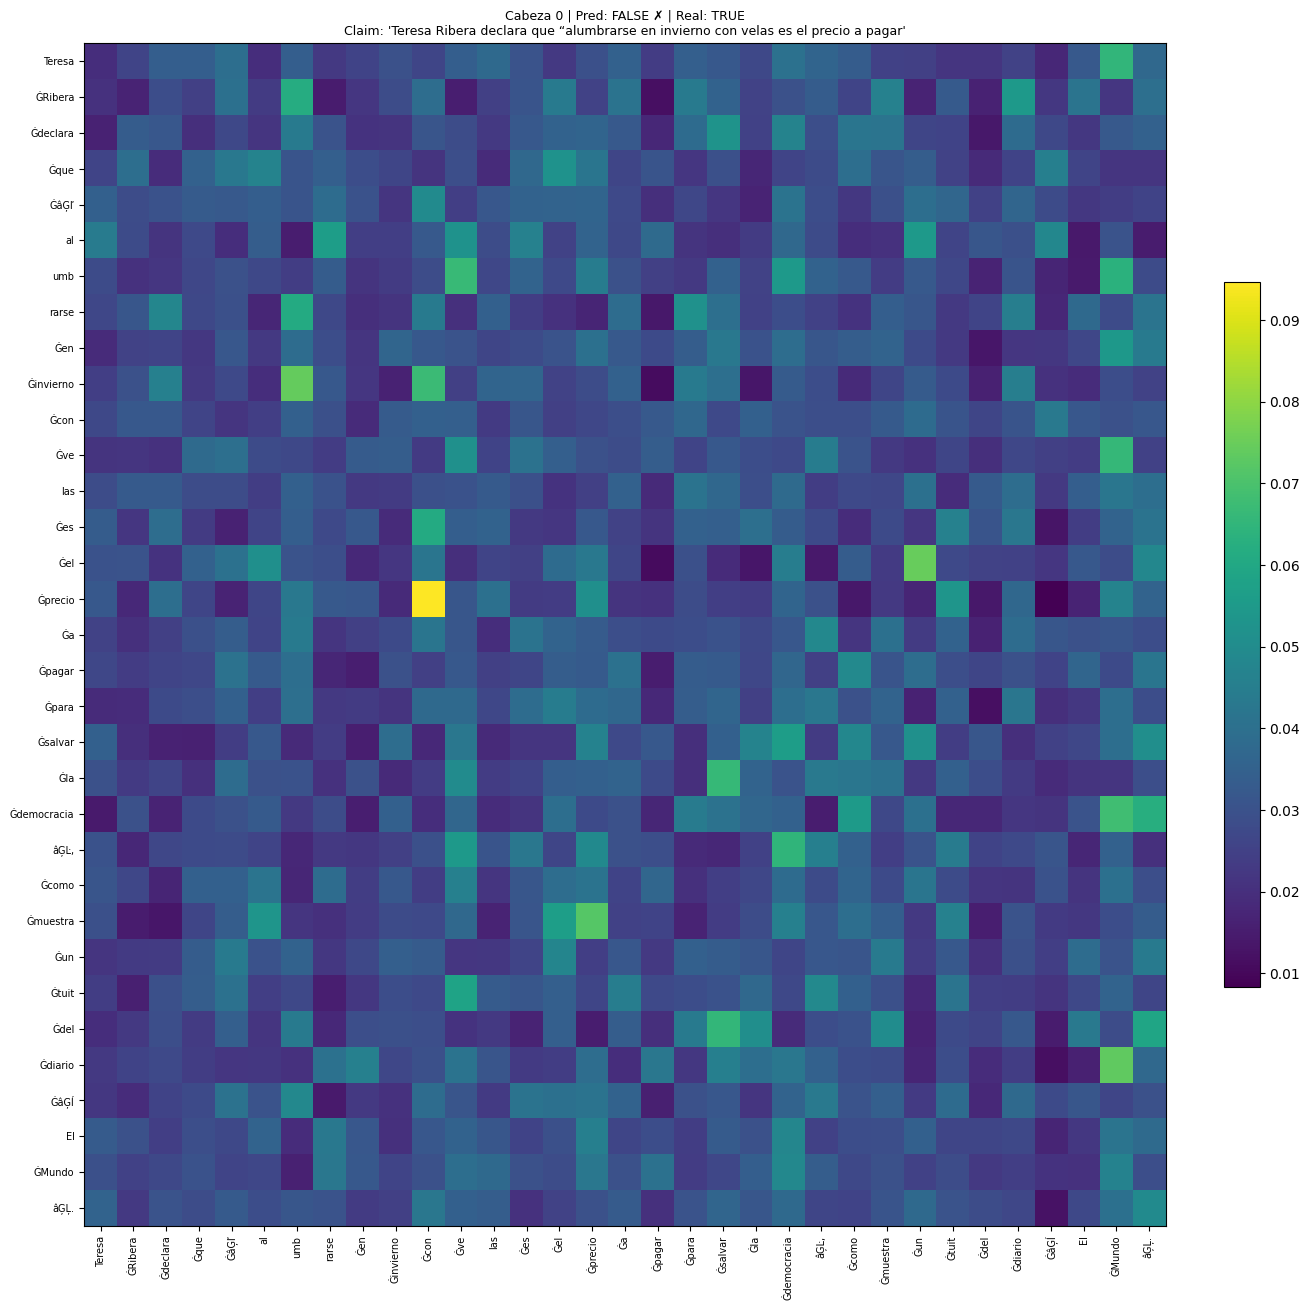


Interpretación:
- En claims FALSE esperamos atención concentrada en cifras, nombres propios
  y afirmaciones superlativas que suelen ser el eje de la desinformación.
- En claims TRUE, la atención puede distribuirse más uniformemente.
- En MIXTURE, la atención puede dividirse entre fragmentos verdaderos
  y fragmentos problemáticos del mismo claim.



In [30]:
def plot_attention(model, tokenizer, text, true_label=None,
                   id_2_class=None, seq_length=128, head=0):
    """Visualiza el mapa de atención de una cabeza específica para un claim."""
    model.eval()
    device = next(model.parameters()).device

    enc      = tokenizer(text, max_length=seq_length, truncation=True, padding='max_length')
    x        = torch.tensor(enc['input_ids']).unsqueeze(0).to(device)
    mask     = torch.tensor(enc['attention_mask']).unsqueeze(0).to(device)
    real_len = sum(enc['attention_mask'])
    tok_strs = enc.tokens()[:real_len]

    with torch.no_grad():
        emb = model.embeddings(x)
        _, attn_w = model.transformer(emb, mask, return_attention=True)
        attn_map  = attn_w[0, head, :real_len, :real_len].cpu().numpy()
        logits    = model(x, mask)
        pred_lbl  = id_2_class[logits.argmax(dim=-1).item()]

    correct = '✓' if true_label == pred_lbl else '✗'
    size    = min(real_len * 0.4, 14)

    fig, ax = plt.subplots(figsize=(size, size))
    im = ax.imshow(attn_map, cmap='viridis', aspect='auto')
    ax.set_xticks(range(real_len))
    ax.set_yticks(range(real_len))
    ax.set_xticklabels(tok_strs, rotation=90, fontsize=7)
    ax.set_yticklabels(tok_strs, fontsize=7)
    ax.set_title(
        f"Cabeza {head} | Pred: {pred_lbl} {correct} | Real: {true_label}\n"
        f"Claim: '{text[:80]}'",
        fontsize=9
    )
    plt.colorbar(im, ax=ax, fraction=0.03)
    plt.tight_layout()
    return fig, pred_lbl


# Visualizar un claim por etiqueta del test set
shown = {}
for txt, lbl in zip(X_test, y_test):
    if lbl not in shown:
        shown[lbl] = txt
    if len(shown) == train_ds.num_classes:
        break

for lbl, txt in shown.items():
    fig, pred = plot_attention(
        model, newspolyml_tokenizer, txt,
        true_label=lbl, id_2_class=train_ds.id_2_class, head=0
    )
    plt.savefig(f'attn_{lbl.lower()}.png', dpi=100, bbox_inches='tight')
    plt.show()

print("""
Interpretación:
- En claims FALSE esperamos atención concentrada en cifras, nombres propios
  y afirmaciones superlativas que suelen ser el eje de la desinformación.
- En claims TRUE, la atención puede distribuirse más uniformemente.
- En MIXTURE, la atención puede dividirse entre fragmentos verdaderos
  y fragmentos problemáticos del mismo claim.
""")

## 9. Análisis de errores

In [31]:
rows = []
for i, (txt, lbl) in enumerate(zip(X_test, y_test)):
    rows.append({
        'claim':      txt,
        'real':       lbl,
        'prediccion': train_ds.id_2_class[all_preds[i]],
        'char_len':   len(txt)
    })

df_results = pd.DataFrame(rows)
df_errors  = df_results[df_results['real'] != df_results['prediccion']]

print(f'Total errores: {len(df_errors):,} / {len(df_results):,} '
      f'({100*len(df_errors)/len(df_results):.1f}%)')

print('\nPares de confusión más frecuentes:')
print(
    df_errors.groupby(['real', 'prediccion'])
    .size().sort_values(ascending=False)
    .head(10).to_string()
)

print('\n--- 6 ejemplos de errores ---')
for _, row in df_errors.sample(min(6, len(df_errors)), random_state=42).iterrows():
    print(f"  Real: {row['real']:8s} | Pred: {row['prediccion']}")
    print(f"  Claim: {row['claim'][:100]}")
    print()

Total errores: 304 / 1,486 (20.5%)

Pares de confusión más frecuentes:
real     prediccion
MIXTURE  FALSE         255
TRUE     FALSE          49

--- 6 ejemplos de errores ---
  Real: MIXTURE  | Pred: FALSE
  Claim: La falta de calcio provoca dengue

  Real: MIXTURE  | Pred: FALSE
  Claim: Noticia del diario Bild: Refugiados ucranianos en Alemania queman la casa en la que residían al inte

  Real: MIXTURE  | Pred: FALSE
  Claim: Autobuses llevaron gente para asistir a la presentación del libro de CFK Cristina Kirchner

  Real: TRUE     | Pred: FALSE
  Claim: Exvicepresidente de Estados Unidos Mike Pence golpeado con un globo de agua

  Real: MIXTURE  | Pred: FALSE
  Claim: Fijos discontinuos: la figura sustituta de los contratos temporales que le pondrá el colorete a los 

  Real: TRUE     | Pred: FALSE
  Claim: Teresa Ribera declara que “alumbrarse en invierno con velas es el precio a pagar para salvar la demo



## 10. Conclusiones

### Resultados obtenidos

| Métrica       | Valor  |
|---------------|--------|
| Test Accuracy | 0.7954 |
| Test F1-macro | 0.2954 |

### Interpretación

El modelo colapsa hacia la clase mayoritaria (FALSE), prediciendo FALSE
para la totalidad de los ejemplos del test set. Esto queda evidenciado
en la matriz de confusión: recall = 1.00 para FALSE y recall = 0.00
para MIXTURE y TRUE.

Las causas identificables son:

**1. Desbalance extremo (79.5% FALSE en español).**
Con esta proporción, el mínimo de pérdida más accesible para un modelo
entrenado desde cero es predecir siempre la clase mayoritaria. Los pesos
de clase en la función de pérdida mitigan pero no eliminan este sesgo
cuando el desbalance supera el 75%.

**2. Volumen insuficiente en clases minoritarias.**
TRUE tiene apenas 325 ejemplos en entrenamiento y OTHER/MIXTURE 1,619.
Un transformer sin pre-entrenamiento necesita miles de ejemplos por clase
para construir representaciones semánticas útiles desde cero.

**3. Capacidad representacional de una sola capa.**
Detectar desinformación requiere razonamiento factual: comparar la
afirmación con conocimiento del mundo, identificar inconsistencias lógicas,
reconocer patrones de manipulación. Una sola capa de Multi-Head Attention
solo captura co-ocurrencias superficiales de tokens, insuficiente para
este tipo de inferencia.

### Comparativa con el notebook guía

| Aspecto | Guía (noticias, 12 clases) | Este notebook (desinformación, 3 clases) |
|---|---|---|
| Test Accuracy | 0.782 | 0.795 |
| F1-macro | ~0.75 (balanceado) | 0.30 (colapsado) |
| Clases aprendidas | 12/12 | 1/3 |
| Desbalance | Moderado | Severo (79.5%) |


